In [2]:
import xgboost as xgb
import pandas as pd
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
import shap

In [103]:
df = pd.read_csv('dataset_1_v2.csv')

In [101]:
def add_neighbors(size, value_col, df_result):
    # Directions to shift (row_offset, col_offset)
    width = size // 2
    dirs = [(i, j) for i in range(-width, width + 1) for j in range(-width, width + 1)]

    df_result.sort_values(by=['row', 'col', 'date'], inplace=True)


    for i, (dr, dc) in enumerate(dirs):
        shifted = df_result[['row', 'col', 'date', value_col]].copy()
        shifted['row'] += dr
        shifted['col'] += dc
        shifted = shifted.rename(columns={value_col: f'{value_col}_({dr}, {dc})'})

        # Merge shifted column into the main DataFrame
        df_result = df_result.merge(shifted, on=['row', 'col', 'date'], how='left')

    return df_result


In [104]:
df = add_neighbors(5, 'frp', df)

In [105]:
df = df.dropna()

In [106]:
neighbor_cols = [col for col in df.columns if col.startswith('frp_(')]
df.loc[:, 'frp_5x5_mean'] = df[neighbor_cols].mean(axis=1)


In [109]:
df['wind_speed'] = np.sqrt(df['u_wind_10m'] ** 2 + df['v_wind_10m'] ** 2)
df['frp_5x5_mean_x_wind_speed'] = df['frp_5x5_mean'] * df['wind_speed']
df['delta_pm25_t_x_temp'] = df['delta_pm25_t'] * df['temp_2m']
df['wind_speed_x_precip'] = df['wind_speed'] * df['precip_sum']
df['wind_speed_/_surf_press'] = df['wind_speed'] / df['surf_pressure']

In [130]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['week'] = pd.to_datetime(df['date']).dt.isocalendar().week


In [120]:
elnino_years = [1997, 2002, 2009, 2015, 2019, 2023]
df['year'] = pd.to_datetime(df['date']).dt.year
df['elnino_flag'] = df['year'].isin(elnino_years).astype(int)

In [124]:
df['elnino_x_month'] = df['elnino_flag'] * df['month']

In [126]:
df['elnino_x_frp'] = df['elnino_flag'] * df['frp_5x5_mean']

In [121]:
df=df.drop('year', axis=1)

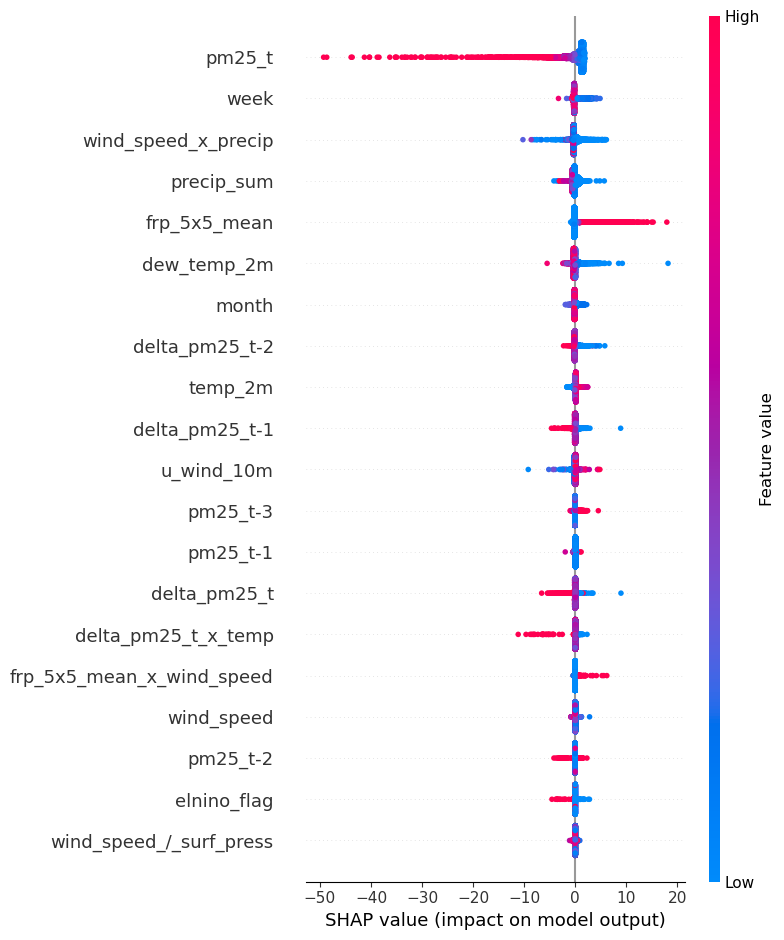

In [131]:
train = df.sample(n=int(1e5), random_state=42)

X_train = train.drop(['row', 'col', 'date', 'delta_pm25_t+1'], axis=1)
y_train = train['delta_pm25_t+1']

model = xgb.XGBRegressor(
    max_depth=3,
    learning_rate=0.1,
    n_estimators=100
)
model.fit(X_train, y_train)


# Create the SHAP explainer for tree-based models
explainer = shap.Explainer(model)

# Get SHAP values for your data (e.g., training or validation set)
shap_values = explainer(X_train)

X_sample = X_train.sample(n=10000, random_state=42)
shap_values = explainer.shap_values(X_sample)

# Summary plot (global feature importance)
shap.summary_plot(shap_values, X_sample)

In [129]:
df.to_csv('dataset_1_v3.csv', index=False)